In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Working with connectomes in Python

In [2]:
# Load connectome
connectivity_data = '/Users/dollomab/OtherProjects/eitn2025-python-tutorial/data/connectivity_76/' # Path to connectivity data
weights_file = f'{connectivity_data}/weights.txt' # Path to weights file
weights = np.loadtxt(weights_file) # Load weights into a NumPy array

print('Array shape: ', weights.shape) # Print the shape of the array
print('Array: \n', weights) # Print the array contents

Array shape:  (76, 76)
Array: 
 [[2. 2. 0. ... 0. 0. 0.]
 [3. 2. 0. ... 0. 0. 0.]
 [0. 0. 2. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 2. 2. 0.]
 [0. 0. 0. ... 3. 2. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


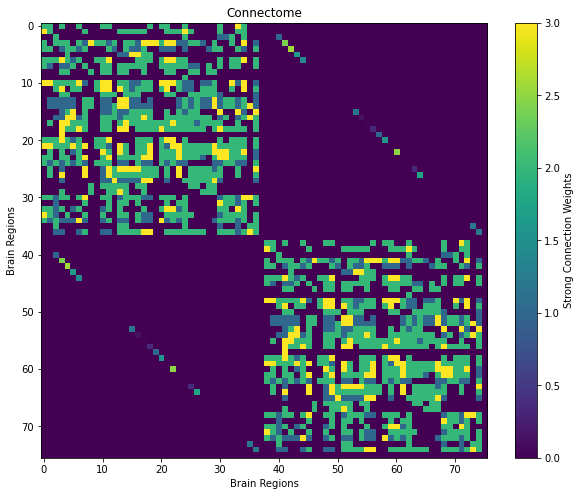

In [3]:
# Plot the connectome
def plot_connectome(weights, region_labels=None, title='Connectome'):
    plt.figure(figsize=(10, 8))
    plt.imshow(weights, cmap='viridis', aspect='auto')
    plt.colorbar(label='Strong Connection Weights')
    plt.title(title)
    plt.xlabel('Brain Regions')
    plt.ylabel('Brain Regions')
    if region_labels is not None:
        plt.xticks(ticks=np.arange(len(region_labels)), labels=region_labels, rotation=90)
        plt.yticks(ticks=np.arange(len(region_labels)), labels=region_labels)
    plt.show()

plot_connectome(weights)

Shape: (76, 76)
Any NaNs? False


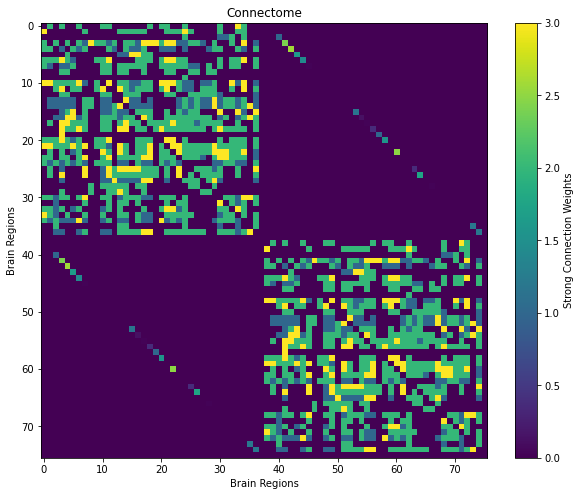

In [4]:
# Basic checks
assert weights.ndim == 2, "weights must be 2D"
n, m = weights.shape
assert n == m, f"weights must be square (got {weights.shape})"
print("Shape:", weights.shape)
print("Any NaNs?", np.isnan(weights).any())

# Remove self-connections
np.fill_diagonal(weights, 0)

# Re-plot the connectome with self-connections removed
plot_connectome(weights)

In [5]:
# Load centres
centres_file = f'{connectivity_data}/centres.txt' # Path to centres file
centres = np.loadtxt(centres_file, dtype=str) # Load centres into a NumPy array

print('Array shape: ', centres.shape) # Print the shape of the array
print('Array snippet: \n', centres[:10])  # Print first 10 entries

Array shape:  (76, 4)
Array snippet: 
 [['rA1' '-9.885591' '-47.084818' '-3.139360']
 ['rA2' '-2.605247' '-55.324507' '-7.065423']
 ['rAMYG' '6.489431' '-11.670519' '-30.851544']
 ['rCCA' '48.734149' '-2.004701' '8.019123']
 ['rCCP' '-12.171400' '-6.494719' '25.361539']
 ['rCCR' '-38.152500' '-13.054752' '-5.607666']
 ['rCCS' '30.150795' '-4.286333' '-31.136279']
 ['rFEF' '30.400644' '-33.753689' '34.832572']
 ['rG' '36.159029' '-35.084312' '-18.938829']
 ['rHC' '-12.502286' '-24.875165' '-20.872351']]


In [6]:
regions = centres[:, 0] # Extract region names
print('Number of regions: ', len(regions))  # Print number of regions
print('Brain regions: \n', regions) # Print region names

'''
Notes on some brain region abbreviations:
A1 / A2 - Primary / Secondary Auditory Cortex
AMYG - Amygdala
CCA - Anterior Cingulate Cortex
CCP - Posterior Cingulate Cortex
CCR - Rostral Cingulate Cortex
CCS - Subcallocular Cingulate Cortex
M1 - Primary Motor Cortex
S1 - Primary Somatosensory Cortex
PCI - Parietal cortex inferior 
V1/V2 - Primary / Secondary Visual Cortex
PFCDL - Prefrontal Cortex Dorsolateral
PFCM - Prefrontal Cortex Medial
PFCVL - Prefrontal Cortex Ventral
PFCORB - Orbitofrontal Cortex
PFCPOL - Prefrontal polar region (frontal pole)
PCM - Parietal cortex medial
TCI - Temporal cortex inferior
TCS - Temporal cortex superior
'''

Number of regions:  76
Brain regions: 
 ['rA1' 'rA2' 'rAMYG' 'rCCA' 'rCCP' 'rCCR' 'rCCS' 'rFEF' 'rG' 'rHC' 'rIA'
 'rIP' 'rM1' 'rPCI' 'rPCIP' 'rPCM' 'rPCS' 'rPFCCL' 'rPFCDL' 'rPFCDM'
 'rPFCM' 'rPFCORB' 'rPFCPOL' 'rPFCVL' 'rPHC' 'rPMCDL' 'rPMCM' 'rPMCVL'
 'rS1' 'rS2' 'rTCC' 'rTCI' 'rTCPOL' 'rTCS' 'rTCV' 'rV1' 'rV2' 'rCC' 'lA1'
 'lA2' 'lAMYG' 'lCCA' 'lCCP' 'lCCR' 'lCCS' 'lFEF' 'lG' 'lHC' 'lIA' 'lIP'
 'lM1' 'lPCI' 'lPCIP' 'lPCM' 'lPCS' 'lPFCCL' 'lPFCDL' 'lPFCDM' 'lPFCM'
 'lPFCORB' 'lPFCPOL' 'lPFCVL' 'lPHC' 'lPMCDL' 'lPMCM' 'lPMCVL' 'lS1' 'lS2'
 'lTCC' 'lTCI' 'lTCPOL' 'lTCS' 'lTCV' 'lV1' 'lV2' 'lCC']


'\nNotes on some brain region abbreviations:\nA1 / A2 - Primary / Secondary Auditory Cortex\nAMYG - Amygdala\nCCA - Anterior Cingulate Cortex\nCCP - Posterior Cingulate Cortex\nCCR - Rostral Cingulate Cortex\nCCS - Subcallocular Cingulate Cortex\nM1 - Primary Motor Cortex\nS1 - Primary Somatosensory Cortex\nPCI - Parietal cortex inferior \nV1/V2 - Primary / Secondary Visual Cortex\nPFCDL - Prefrontal Cortex Dorsolateral\nPFCM - Prefrontal Cortex Medial\nPFCVL - Prefrontal Cortex Ventral\nPFCORB - Orbitofrontal Cortex\nPFCPOL - Prefrontal polar region (frontal pole)\nPCM - Parietal cortex medial\nTCI - Temporal cortex inferior\nTCS - Temporal cortex superior\n'

In [7]:
# Node strengths (sum of weights per node)
strengths = weights.sum(axis=1)
print("Top 10 nodes by strength (idx, strength):")
top_idx = np.argsort(strengths)[::-1][:10]
for i in top_idx:
    print(regions[i], strengths[i])

Top 10 nodes by strength (idx, strength):
rPFCORB 70.0
lPFCORB 70.0
rPFCPOL 60.4880117
lPFCPOL 60.4879251
rPFCDL 60.37354144
lPFCDL 60.37351909
lPFCVL 60.0
rPFCVL 60.0
rCCA 58.4074291
lCCA 58.4073365


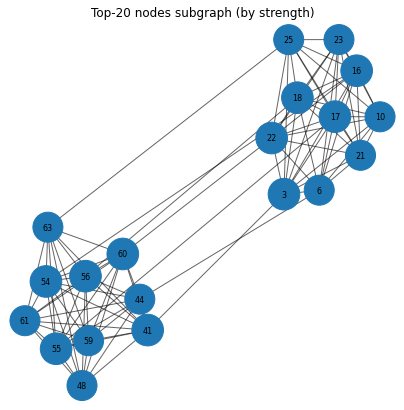

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

# Plot a subgraph of top-20 nodes by strength
top_nodes = np.argsort(strengths)[::-1][:20]
G_sub = nx.from_numpy_array(weights[np.ix_(top_nodes, top_nodes)])
pos = nx.spring_layout(G_sub, seed=1)
plt.figure(figsize=(7,7))
nx.draw_networkx_nodes(G_sub, pos, node_size=[v*100 for _,v in G_sub.degree()])
nx.draw_networkx_edges(G_sub, pos, alpha=0.6)
nx.draw_networkx_labels(G_sub, pos, labels={i:str(top_nodes[i]) for i in range(len(top_nodes))}, font_size=8)
plt.title('Top-20 nodes subgraph (by strength)')
plt.axis('off')
plt.show()

Sub-network shape:  (10, 10)
Sub-network: 
 [[0. 2. 0. 2. 0. 0. 2. 0. 0. 0.]
 [3. 0. 0. 0. 0. 0. 0. 2. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [2. 0. 2. 0. 2. 0. 2. 1. 3. 2.]
 [2. 2. 0. 1. 0. 2. 1. 2. 0. 0.]
 [0. 0. 0. 0. 2. 0. 0. 0. 0. 0.]
 [2. 2. 2. 3. 2. 1. 0. 0. 0. 2.]
 [2. 1. 0. 1. 1. 2. 0. 0. 0. 0.]
 [0. 0. 0. 2. 2. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


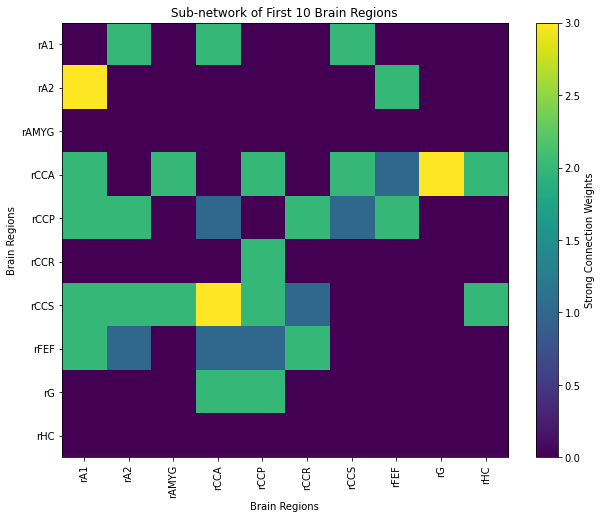

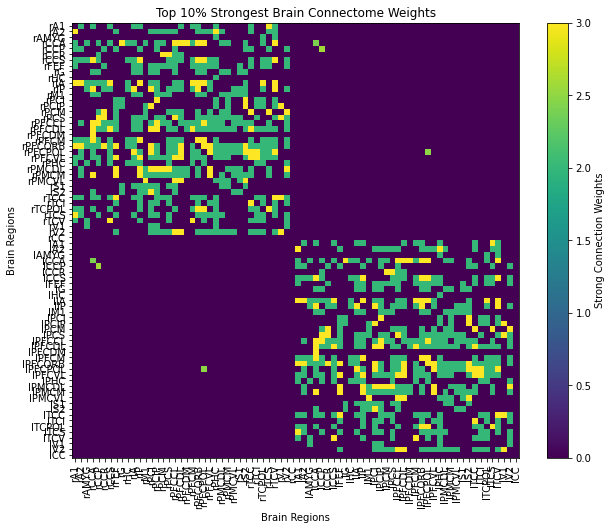

In [9]:
# Manipulating connectivity matrix can involve thresholding, normalizing, or extracting sub-networks.
# Let's extract a sub-network of the first 10 regions as an example.
sub_network = weights[:10, :10]
print('Sub-network shape: ', sub_network.shape)
print('Sub-network: \n', sub_network)

plot_connectome(sub_network, region_labels=regions[:10], title='Sub-network of First 10 Brain Regions')

# Let's try to highlight the strongest connections
threshold = np.percentile(weights, 95)  # Top 5% connections
strong_connections = np.where(weights >= threshold, weights, 0)

plot_connectome(strong_connections, region_labels=regions, title='Top 10% Strongest Brain Connectome Weights')

Tract lengths shape:  (76, 76)
Tract lengths snippet: 
 [[ 0.       20.330072 32.876029 45.482256 43.214474 35.009035 49.907616
  32.201254 46.189785 22.765599]
 [20.330072  0.       46.623042 65.051623 56.046734 49.207991 68.288987
  36.253248 57.250471 33.157034]
 [32.876029 46.623042  0.       50.377749 55.580848 38.835007 30.528956
  60.688806 36.808281 23.316864]
 [45.482256 65.051623 50.377749  0.       42.488013 42.72864  37.443605
  50.720057 56.303979 52.556682]
 [43.214474 56.046734 55.580848 42.488013  0.       18.639023 63.81033
  60.005728 80.093396 40.353027]
 [35.009035 49.207991 38.835007 42.72864  18.639023  0.       52.007998
  60.389498 68.252187 24.426625]
 [49.907616 68.288987 30.528956 37.443605 63.81033  52.007998  0.
  66.281416 34.25607  48.755171]
 [32.201254 36.253248 60.688806 50.720057 60.005728 60.389498 66.281416
   0.       55.159445 54.830903]
 [46.189785 57.250471 36.808281 56.303979 80.093396 68.252187 34.25607
  55.159445  0.       53.889008]
 [22.76

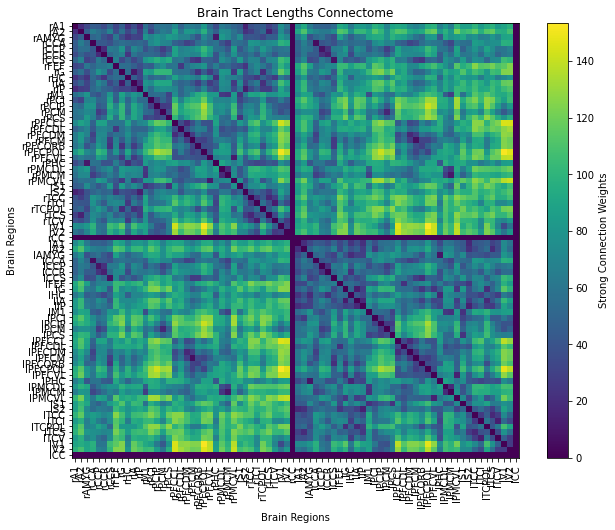

In [11]:
# Plot tract lengths matrix
tract_lengths_file = f'{connectivity_data}/tract_lengths.txt' # Path to tract lengths file
tract_lengths = np.loadtxt(tract_lengths_file) # Load tract lengths into a NumPy array
print('Tract lengths shape: ', tract_lengths.shape) # Print the shape of the array
print('Tract lengths snippet: \n', tract_lengths[:10, :10])
plot_connectome(tract_lengths, region_labels=regions, title='Brain Tract Lengths Connectome')


## Bonus: making 3D plots

In [10]:
# To install plotly in your environment, uncomment and run the following line in a notebook cell:
# %pip install plotly

import plotly.graph_objects as go
x = centres[:, 1].astype(float)
y = centres[:, 2].astype(float)
z = centres[:, 3].astype(float)
labels = list(regions) if 'regions' in globals() else [str(i) for i in range(len(x))]
colors = ['purple' if lab.startswith('r') else 'darkblue' if lab.startswith('l') else 'gray' for lab in labels]

fig = go.Figure(data=[go.Scatter3d(
    x=x, y=y, z=z, mode='markers',
    marker=dict(size=5, color=colors, opacity=0.8),
    text=labels,
    hovertemplate="%{text}<br>x=%{x:.2f}<br>y=%{y:.2f}<br>z=%{z:.2f}<extra></extra>"
)])
fig.update_layout(scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'),
                  title='3D Brain Region Centres (Plotly)')
fig.show()

If all of this was too easy, go ahead and run the *plot_3D_connectome.py* script to see a full 3D connectome visualization!